In [10]:
# !pip install matplotlib 
#!pip install seaborn

# EDA

## Loading Court cases FIle

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv('../court_cases.csv', parse_dates=['Date'])
df.head()

,Case_Number,Coram,Judge,Date,Tribunal_Court,Plaintiff_Name,Defendant_Name,Combined_Facts,Combined_Issue,Combined_Rule,Combined_Application,plaintiff_label,defendant_label
0,Suit 798/2007,Judith Prakash J,Judith Prakash,2009-07-06,High Court,ABB Holdings Pte Ltd,Sher Hock Guan Charles,"[[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '19...","['Whether, based on the pre-2003 employment co...","['Under employment and company law, the obliga...",['ABB Holdings Pte Ltd issued and administered...,Claim Dismissed,Liable
1,Suit 798/2007,Judith Prakash J,Judith Prakash,2009-07-06,High Court,ABB Installation Materials (East Asia) Pte Ltd,Sher Hock Guan Charles,"[[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '19...",['Whether the pre-2003 conduct of Sher Hock Gu...,['Company officers and senior managers must av...,['ABB Installation Materials (East Asia) Pte L...,Claim Dismissed,Liable
2,Suit 798/2007,Judith Prakash J,Judith Prakash,2009-07-06,High Court,ABB Industry Pte Ltd,Sher Hock Guan Charles,"[[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '19...","['Whether, before and up to February 2003, the...",['Senior managers responsible for a business a...,['While serving as General Manager and Vice-Pr...,Claim Allowed,Liable
3,Suit No 477 of 2012; Suit No 1015 of 2012; Reg...,George Wei JC,George Wei,2014-02-14,High Court,Airtrust (Singapore) Pte Ltd (AT) – Suit No 47...,Kao Chai-Chau Linda,"[[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '20...","['Whether, in Suit No 477 of 2012, losses to A...",['Where multiple persons are each legally resp...,"['Airtrust (Singapore) Pte Ltd, through the de...",Claim Allowed,Liable
4,Suit No 477 of 2012; Suit No 1015 of 2012; Reg...,George Wei JC,George Wei,2014-02-14,High Court,Airtrust (Singapore) Pte Ltd (AT) – Suit No 47...,Estate of Peter Fong,"[[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '20...","['Whether, in Suit No 477 of 2012, losses to A...",['Where multiple persons are each legally resp...,"['Airtrust (Singapore) Pte Ltd, through the de...",Claim Allowed,Liable


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Case_Number           424 non-null    str           
 1   Coram                 424 non-null    str           
 2   Judge                 424 non-null    str           
 3   Date                  424 non-null    datetime64[us]
 4   Tribunal_Court        424 non-null    str           
 5   Plaintiff_Name        424 non-null    str           
 6   Defendant_Name        424 non-null    str           
 7   Combined_Facts        424 non-null    str           
 8   Combined_Issue        424 non-null    str           
 9   Combined_Rule         424 non-null    str           
 10  Combined_Application  424 non-null    str           
 11  plaintiff_label       424 non-null    str           
 12  defendant_label       424 non-null    str           
dtypes: datetime64[us](1), str(12)
m

In [32]:
df.isnull().sum()

Case_Number             0
Coram                   0
Judge                   0
Date                    0
Tribunal_Court          0
Plaintiff_Name          0
Defendant_Name          0
Combined_Facts          0
Combined_Issue          0
Combined_Rule           0
Combined_Application    0
plaintiff_label         0
defendant_label         0
dtype: int64

In [33]:
cat_cols = ["Tribunal_Court", "plaintiff_label", "defendant_label"]
for col in cat_cols:
    print(f"\n--- {col} ---")
    vc = df[col].value_counts()
    print(vc.to_string())
 
print(f"\n--- Unique Judges ({df['Judge'].nunique()}) ---")
print(df["Judge"].value_counts().head(15).to_string())


--- Tribunal_Court ---
Tribunal_Court
High Court                                                         140
General Division of the High Court of the Republic of Singapore    109
High Court of the Republic of Singapore                             77
High Court of Singapore                                             34
Court of Appeal of the Republic of Singapore                        25
Court of Appeal                                                     20
General Division of the High Court of Singapore                     11
Singapore International Commercial Court                             5
Appellate Division of the High Court of Singapore                    3

--- plaintiff_label ---
plaintiff_label
Claim Allowed            252
Claim Dismissed          163
Claim Allowed In Part      9

--- defendant_label ---
defendant_label
Not Liable    213
Liable        211

--- Unique Judges (60) ---
Judge
Lai Siu Chiu           24
Mohamed Faizal         24
Kannan Ramesh          23
Hri K

In [34]:
print(f"Date range : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"Cases by year:\n{df['Date'].dt.year.value_counts().sort_index().to_string()}")

Date range : 2000-07-03  →  2025-08-06
Cases by year:
Date
2000     4
2001     5
2002     1
2003    39
2004    26
2005     2
2006     9
2007    12
2008     4
2009     3
2010     8
2011     3
2012     4
2013    29
2014    18
2015     5
2016    25
2017    27
2018    20
2019    26
2020    19
2021    21
2022    26
2023     4
2024    41
2025    43


In [35]:
text_cols = ["Combined_Facts", "Combined_Issue", "Combined_Rule", "Combined_Application"]
for col in text_cols:
    lengths = df[col].str.len()
    print(f"\n{col}:")
    print(f"  min={lengths.min():,}  median={lengths.median():,.0f}  "
          f"mean={lengths.mean():,.0f}  max={lengths.max():,}")


Combined_Facts:
  min=428  median=7,119  mean=8,768  max=36,629

Combined_Issue:
  min=275  median=493  mean=512  max=1,262

Combined_Rule:
  min=334  median=722  mean=784  max=2,016

Combined_Application:
  min=353  median=1,192  mean=1,318  max=4,088


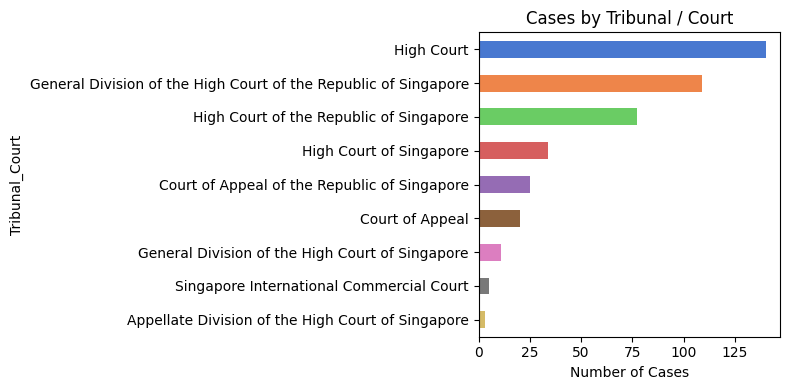

In [36]:
fig, ax = plt.subplots(figsize=(8, 4))
vc = df["Tribunal_Court"].value_counts()
vc.plot(kind="barh", ax=ax, color=sns.color_palette("muted", len(vc)))
ax.set_title("Cases by Tribunal / Court")
ax.set_xlabel("Number of Cases")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
# do data cleaning on this

In [37]:
court_mapping = {
    "High Court": "High Court of Singapore",
    "High Court of the Republic of Singapore": "High Court of Singapore",
    "High Court of Singapore": "High Court of Singapore",

    "General Division of the High Court of the Republic of Singapore": "General Division of the High Court of Singapore",
    "General Division of the High Court of Singapore": "General Division of the High Court of Singapore",

    "Court of Appeal": "Court of Appeal",
    "Court of Appeal of the Republic of Singapore": "Court of Appeal",

    "Singapore International Commercial Court": "Singapore International Commercial Court",

    "Appellate Division of the High Court of Singapore": "Appellate Division of the High Court of Singapore",
}

df["Tribunal_Court"] = df["Tribunal_Court"].map(court_mapping).fillna(df["Tribunal_Court"])


In [38]:
print(df["Tribunal_Court"].value_counts())


Tribunal_Court
High Court of Singapore                              251
General Division of the High Court of Singapore      120
Court of Appeal                                       45
Singapore International Commercial Court               5
Appellate Division of the High Court of Singapore      3
Name: count, dtype: int64
